<a href="https://colab.research.google.com/github/alexmordashov/image_processing/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%20%E2%84%962/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961_%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%BE%D0%B1%D1%8A%D0%B5%D0%BA%D1%82%D0%BE%D0%B2_%D0%BD%D0%B0_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Проектная работа №1: Классификация объектов на изображении**

### **Цель:**

Разработать программу на Python, которая принимает на вход фотографию с изображением монет и вычисляет общую сумму денежных средств, отображенных на ней, используя только библиотеку OpenCV и стандартные библиотеки Python.

### **Базовая реализация:**

1. **Сбор изображения:**
   - Используйте камеру или загрузите готовое изображение с монетами для обработки.

2. **Предварительная обработка изображения:**
   - Преобразуйте изображение в оттенки серого.
   - Примените размытие Гаусса для уменьшения шума.
   - Используйте оператор Кэнни для обнаружения краев.

3. **Обнаружение кругов (монет):**
   - Используйте преобразование Хафа для обнаружения кругов на изображении.
   - Получите координаты центров и радиусов обнаруженных кругов (монет).

4. **Классификация монет:**
   - Определите номинал каждой монеты на основе ее радиуса.
   - Установите пороговые значения для радиусов, соответствующие разным номиналам:
     - **Маленький радиус:** 1 рубль.
     - **Средний радиус:** 2 рубля.
     - **Большой радиус:** 5 рублей.

5. **Подсчет общей суммы:**
   - Суммируйте номиналы всех обнаруженных монет.
   - Отобразите общую сумму на изображении или в консоли.

6. **Отображение результатов:**
   - Нарисуйте окружности на изображении вокруг обнаруженных монет.
   - Подпишите рядом с каждой монетой ее номинал.
   - Покажите исходное изображение с отмеченными монетами.
   - Выведите обработанные этапы для визуализации процесса (например, изображение после предварительной обработки, с контурами и т.д.).

### **Требования к реализации:**

- Использовать только библиотеку **OpenCV** и стандартные библиотеки Python (например, **NumPy**).
- Код должен быть хорошо документирован с комментариями для каждого основного блока.
- Предусмотреть возможность настройки параметров обработки через трекбары или отдельные переменные.


### **Рекомендации:**

- **Преобразование Хафа** для кругов является удобным инструментом для обнаружения круглых объектов на изображении.
- **Пороговые значения радиусов** необходимо подобрать экспериментально, протестировав на образцах монет разных номиналов.
- **Обработка перекрывающихся монет** может потребовать более сложных алгоритмов, таких как водоразделение или использование градиентных признаков.
- Тестируйте программу на различных изображениях с разным количеством и расположением монет, а также при разном освещении.

### **Ожидаемый результат:**

В результате выполнения задания вы получите программу, которая способна:

- Принимать на вход изображение с монетами.
- Обрабатывать изображение и обнаруживать монеты без использования библиотеки cvzone.
- Определять номинал каждой монеты на основе ее радиуса или других признаков.
- Вычислять и отображать общую сумму монет на изображении.

---

**Пример использования программы:**

- Пользователь запускает программу.
- Загружается изображение с монетами.
- Программа обрабатывает изображение, отмечает каждую монету и подписывает ее номинал.
- Отображается изображение с результатами и выводится общая сумма, например: **"Общая сумма: 37 рублей"**.

---

**Заметка:**

Данный проект позволит вам:

- Изучить и применить технологии обработки изображений с помощью OpenCV без привлечения сторонних библиотек.
- Научиться решать практические задачи компьютерного зрения, применяя базовые методы и улучшая их по мере необходимости.

---

**Советы по реализации:**

- **Настройка параметров:**
  - Для преобразования Хафа используйте функцию `cv2.HoughCircles()`.
  - Экспериментируйте с параметрами `dp`, `minDist`, `param1`, `param2`, `minRadius`, `maxRadius`.
- **Отображение результатов:**
  - Используйте функцию `cv2.circle()` для рисования окружностей.
  - Для отображения текста воспользуйтесь `cv2.putText()`.
- **Обработка ошибок:**
  - Обрабатывайте случаи, когда преобразование Хафа не обнаруживает ни одной монеты.
  - Предусмотрите проверку входных данных и вывод информативных сообщений для пользователя.



In [5]:
# Загрузка необходимых библиотек
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

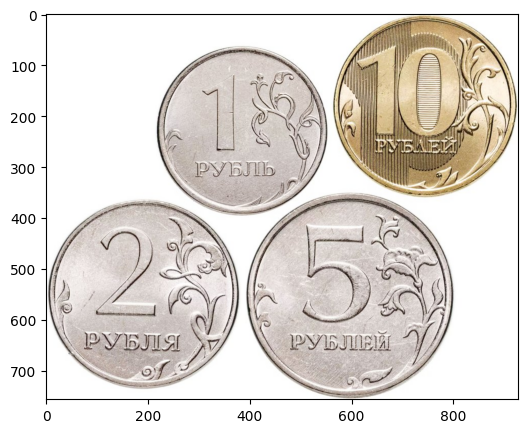

In [6]:
# Сбор изображения
URL = "https://cdn.monetnik.ru/storage/market-lot/62/87/692862/2434653_mainViewLot_2x.jpg"
resp = requests.get(URL, stream=True).raw
img = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(img, cv2.IMREAD_COLOR)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

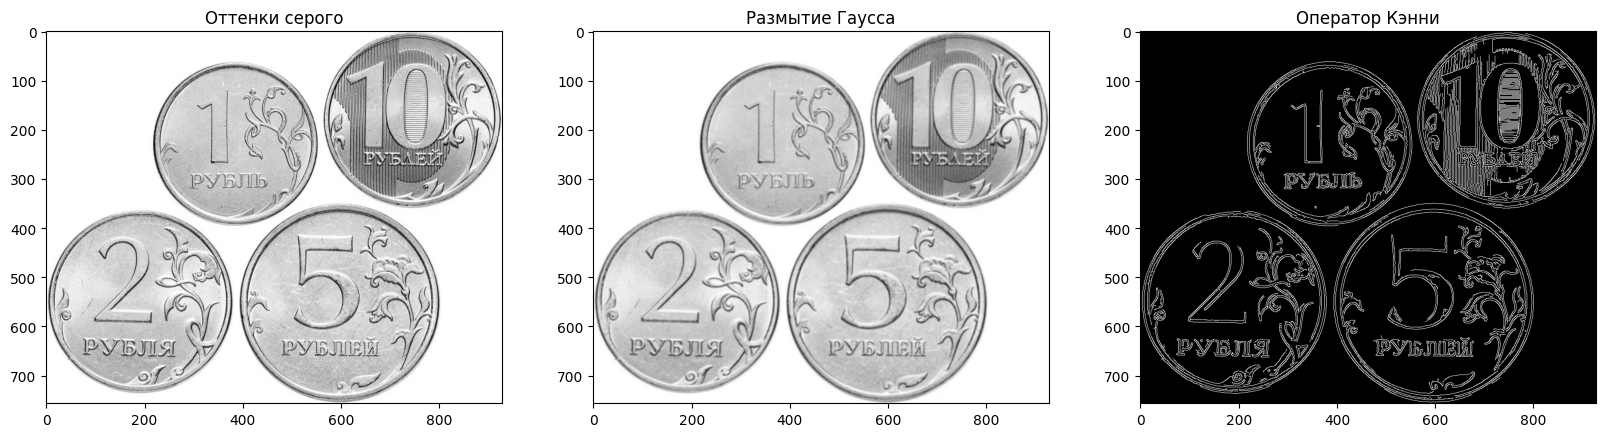

In [81]:
# Предварительная обработка изображения
# Преобразуем изображение в оттенки серого
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Применяем размытие Гаусса для уменьшения шума
gaussian_blur = (1/256) * np.array([
    [1, 4, 6, 4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1, 4, 6, 4, 1]
])
gaussed_img = cv2.filter2D(gray_img, -1, gaussian_blur)
# Используем оператор Кэнни для обнаружения краев
canny_img = cv2.Canny(gaussed_img, 50, 200)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(gray_img, cv2.COLOR_BGR2RGB))
plt.title("Оттенки серого")
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(gaussed_img, cv2.COLOR_BGR2RGB))
plt.title("Размытие Гаусса")
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(canny_img, cv2.COLOR_BGR2RGB))
plt.title("Оператор Кэнни")
plt.show()

In [80]:
# Обнаружение кругов (монет)
# Используем преобразование Хафа для обнаружения кругов на изображении
# Параметры для функции HoughCircles
dp = 1.2                # Параметр разрешения аккумуляторного массива
minDist = 200            # Минимальное расстояние между центрами обнаруженных окружностей
param1 = 50             # Порог для метода Кэнни
param2 = 150            # Порог для функции HoughCircles (чем меньше, тем больше ложных кругов)
minRadius = 100         # Минимальный радиус круга
maxRadius = 250          # Максимальный радиус круга
circles = cv2.HoughCircles(
    canny_img,
    cv2.HOUGH_GRADIENT,
    dp,
    minDist,
    param1=param1,
    param2=param2,
    minRadius=minRadius,
    maxRadius=maxRadius
)

In [84]:
# Словарь с эталонами
COINS = {
    "1":   20.5,
    "2":   23.5,
    "5":   25.0,
    "10":  21.0
}

# Функция для определения номинала монеты
def identify_coin(radius_px, mm_per_px):
  # Вычисляем диаметр монеты
  diameter_mm = 2 * radius_px * mm_per_px

  # Последовательно сравниваем диаметр монеты с эталонным диаметром и выбираем лучший результат
  best = None
  best_diff = float("inf")
  for name, d in COINS.items():
    diff = abs(d - diameter_mm)
    if diff < best_diff:
      best_diff = diff
      best = name

  return best

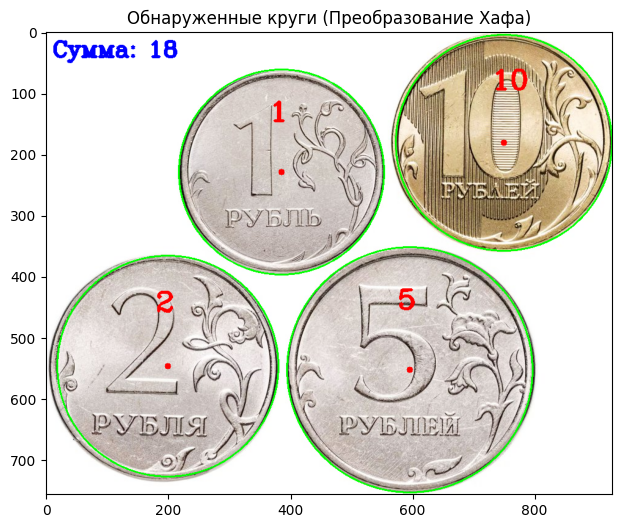

In [85]:
# Получаем координаты центров и радиусов обнаруженных кругов (монет)
# Создание копии изображения для отображения результатов
sum = 0
circles_img = img.copy()
# Проверка, найдены ли круги
if circles is not None:
  #cv2.putText(circles_img, "asdgndtyney", (400, 400), cv2.FONT_HERSHEY_COMPLEX, 1.4, (255, 255, 255), 3)
  # Округление координат центров и радиусов до целых чисел
  circles = np.uint16(np.around(circles))
  for circle in circles[0, :]:
    center = (circle[0], circle[1]) # Координаты центра
    radius = circle[2] # Радиус
    # Определяем номинал монеты
    coin_name = identify_coin(radius, 0.06174698795)
    sum += int(coin_name)
    # Рисуем контур круга
    cv2.circle(circles_img, center, radius, (0, 255, 0), 2)
    # Рисуем центр круга
    cv2.circle(circles_img, center, 5, (0, 0, 255), -1)
    # Подписываем номинал монеты
    cv2.putText(
        circles_img,
        coin_name,
         (center[0] - 20, center[1] - radius // 2),
        cv2.FONT_HERSHEY_COMPLEX,
        1.5,
         (0, 0, 255),
        3
    )
  cv2.putText(
      circles_img,
      "Сумма: " + str(sum),
       (10, 40),
      cv2.FONT_HERSHEY_COMPLEX,
      1.2,
       (255, 0, 0),
      3
  )

else:
  print("Круги не найдены")

# Отображение результатов
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(circles_img, cv2.COLOR_BGR2RGB))
plt.title('Обнаруженные круги (Преобразование Хафа)')
plt.show()